============================ SUMMARY OF THE WORKFLOW ============================
## Here is a simple guide to the variables in your code:

1.  **`X` and `t` (The Training Set)**
    *   **What it is:** This is your **study material** for the model.
    *   `X`: The input questions (100 data points).
    *   `t`: The **noisy answers** to those questions. It's like a real-world answer key that has some small mistakes or variations in it.
    *   **What you do with it:** You use **both `X` and `t`** to **train (or `fit`)** your model. The model's job is to learn the relationship between `X` and `t`, even with the noise.

2.  **`t_true` (The "Perfect" Training Answers)**
    *   **What it is:** These are the *perfect, clean* answers for your training data `X`.
    *   **What you do with it:** In a real project, you would **never have this**. We only have it here to see what the noise-free data looks like. You **do not use this to train your model**, because that would be like giving the student a perfect answer key to memorize, which doesn't teach them how to handle real-world, messy data.

3.  **`X_poly_train` (The Transformed Training Inputs)**
    *   **What it is:** Because a straight line can't fit a sine wave, you need to give your model more powerful features. `PolynomialFeatures` transforms your simple `X` into something more complex like `[x, x², x³, ...]`. This is `X_poly_train`.
    *   **What you do with it:** You feed this, along with `t`, into your `LinearRegression` model to train it.

4.  **`X_test` and `t_test_true` (The Test Set)**
    *   **What it is:** This is the **final exam** for your model. It's brand new data the model has never seen before.
    *   `X_test`: The new, unseen exam questions.
    *   `t_test_true`: The **perfect, correct answers** for the exam. We use the perfect answers for evaluation because we want to know how well the model learned the *true* underlying pattern, not how well it learned the noise.
    *   **What you do with it:** You use this set **only for evaluation**, after the model is already trained.

5.  **`y_pred` (The Model's Predictions)**
    *   **What it is:** These are the answers your model gives for the `X_test` exam questions.
    *   **What you do with it:** You compare `y_pred` to the perfect answers `t_test_true` to see how well your model did. The difference between them is your error (MSE).

---

### Summary of the Workflow

1.  **Get Study Material:** You have `X` (questions) and `t` (noisy answers).
2.  **Prepare for Study:** You transform `X` into `X_poly_train` to make it easier for the model to learn a complex curve.
3.  **Study (Fit/Train):** You train your model using `X_poly_train` and `t`.
4.  **Take the Exam (Predict):** You give the model the new exam questions, `X_test` (which you first transform into `X_poly_test`), and it produces its own answers, `y_pred`.
5.  **Grade the Exam (Evaluate):** You compare the model's answers (`y_pred`) to the perfect answer key (`t_test_true`) to calculate the final score (the MSE).

The main takeaway is: **Train on the noisy data, test against the perfect data.** This is the fundamental concept for building models that can generalize to new, real-world situations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# Generate Synthetic Data
# ---------------------------------------------------------------------------
np.random.seed(1836)
N = 100
X = np.linspace(-10, 10, N).reshape(-1, 1)
t_true = np.sin(X)
t = t_true + 0.1 * np.random.randn(N, 1)

# Test set
X_test = np.linspace(-10, 10, 200).reshape(-1, 1)
t_test_true = np.sin(X_test)

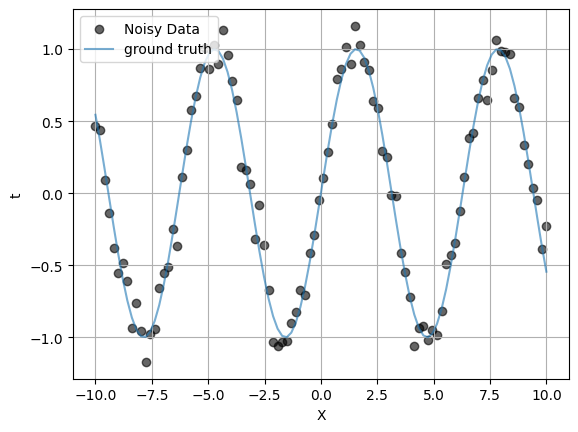

In [2]:
# ---------------------------------------------------------------------------
# Plot results
# ---------------------------------------------------------------------------
# plt.figure(figsize=(12, 7))
plt.scatter(X, t, color="black", alpha=0.6, label="Noisy Data")
plt.plot(X, t_true, alpha=0.6, label="ground truth")
plt.xlabel("X")
plt.ylabel("t")
plt.legend()
plt.grid(True)
plt.show()

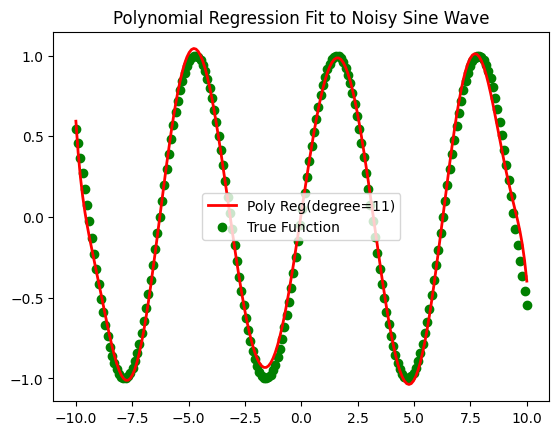

the mean square error is 0.00


In [3]:
# ============================ ADD YOUR CODE HERE ============================

# Fit a Model of your choice and compute the MSE on the test set.
# You should get your MSE as low as possible
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


degree = 11
X_p = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X)
model = LinearRegression()
model.fit(X_p, t)

X_test_p = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_test)
y_pred = model.predict(X_test_p)

# plt.scatter(X, t, color="black", alpha=0.6, label="Noisy Data")
# plt.plot(X, t_true, alpha=0.6, label="ground truth")
# Plot the predicted curve into the figure instatiated above
plt.plot(
    X_test,
    y_pred,
    color="red",
    linewidth=2,
    label=f"Poly Reg(degree={degree})",
)
plt.scatter(X_test, t_test_true, color="green", label="True Function")
plt.title("Polynomial Regression Fit to Noisy Sine Wave")
plt.legend()
plt.show()

# ============================================================================
# Compute MSE
mse = np.mean((t_test_true - y_pred) ** 2)
print(f"the mean square error is {mse:.2f}")